In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df  = pd.read_csv("placement.csv")

df


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


Text(0, 0.5, 'Package')

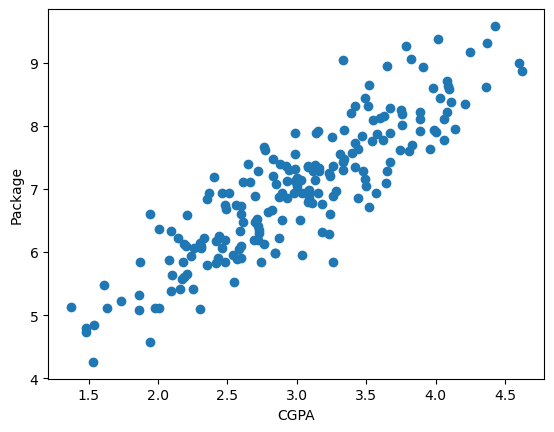

In [10]:

plt.scatter(df['package'],df['cgpa'])
plt.xlabel('CGPA')
plt.ylabel('Package')


In [11]:

X = df.iloc[:,0:1]
Y = df.iloc[:,-1]


In [12]:


from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 2)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train,Y_train)

print(X_test)
print(Y_test)

lr.predict(X_test.iloc[1].values.reshape(1,1))


     cgpa
112  8.58
29   7.15
182  5.88
199  6.22
193  4.57
85   4.79
10   5.32
54   6.86
115  8.35
35   6.87
12   8.94
92   7.90
13   6.93
126  5.91
174  7.32
2    7.82
44   5.09
3    7.42
113  6.94
14   7.73
23   6.19
25   7.28
6    6.73
134  7.20
165  8.21
173  6.75
45   7.87
65   7.60
48   8.63
122  5.12
178  8.15
64   7.36
9    8.31
57   6.60
78   6.59
71   7.47
128  7.93
176  6.29
131  6.37
53   6.47
112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.09324469])


### The Model prediction(Graph):


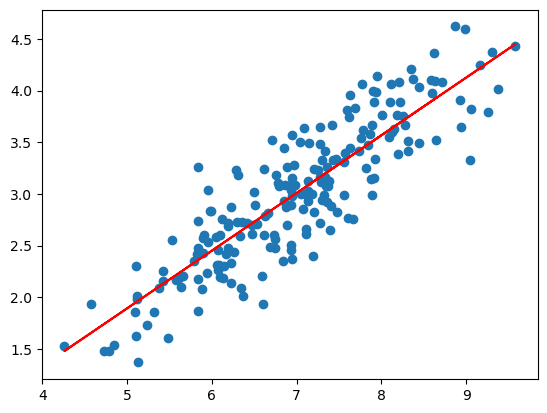

In [13]:

plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')


In [14]:

lr.coef_
lr.intercept_



np.float64(-0.8961119222429126)

# **My OWN Linear Regression Algorithm:**

MAE 0.2884710931878175
MSE 0.12129235313495527
RMSE 0.34827051717731616
R2Score 0.780730147510384
Adjusted R2 Score 0.7688777230514858


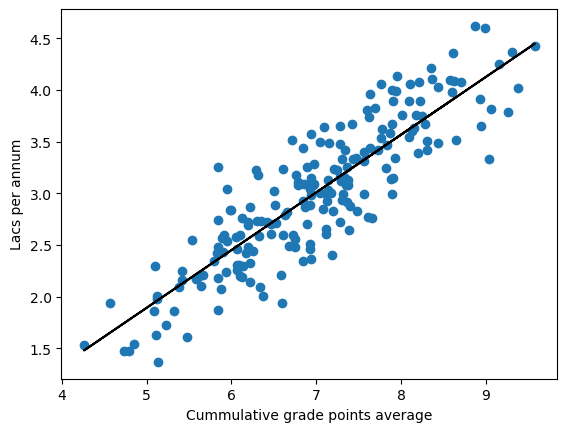

In [15]:


class LR:
    def __init__(self):
        self.m = None
        self.b = None


    def mfit(self,X_train,Y_train):
        num = 0
        den = 0
        Xi = 0
        Xm = 0

        for i in range(X_train.shape[0]):
            
            num +=  (X_train[i] - X_train.mean())*(Y_train[i] - Y_train.mean())
            den += (X_train[i] - X_train.mean())**2


        self.m = num/den
        self.b = (Y_train.mean() - (self.m*X_train.mean()))
        return self.m, self.b
            
        

    def mpredict(self,X_test):
        for i in range(X_test.shape[0]):
            return self.m * X_test + self.b

X = df['cgpa'].values
Y = df['package'].values

mX_train,mX_test,mY_train,mY_test = train_test_split(X,Y,test_size = 0.2, random_state=2)

myLR = LR()
myLR.mfit(mX_train,mY_train)
myLR.mpredict(mX_test[0].reshape(1,1))

# plt.plot(myLR.mpredict(mX_test))
plt.scatter(X,Y)
plt.xlabel("Cummulative grade points average")
plt.ylabel("Lacs per annum")
plt.plot(mX_train,myLR.mpredict(mX_train),color="black")

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

Y_pred =  lr.predict(X_test)

Y_test

print("MAE",mean_absolute_error(Y_test,Y_pred))
print("MSE",mean_squared_error(Y_test,Y_pred))
print("RMSE",np.sqrt(mean_squared_error(Y_test,Y_pred)))
print("R2Score",r2_score(Y_test,Y_pred))
r = r2_score(Y_test,Y_pred)

# Adjusted R2 Score
print("Adjusted R2 Score",1 - ((1-r)*(40-1)/(40-1-2)))
